# Netflix Movies and TV Shows: Exploratory Data Analysis and Extended Insights





This project analyzes the **“Netflix Movies and TV Shows”** dataset from Kaggle, originally compiled
by *shivamb* (https://www.kaggle.com/datasets/shivamb/netflix-shows).


> **“Netflix Movies and TV Shows EDA (Beginner)” by aditimulye**  
> URL: https://www.kaggle.com/code/aditimulye/netflix-movies-and-tv-shows-eda-beginner


1. **Original EDA**  
   - Load and inspect the data  
   - Basic cleaning and handling of missing values  
   - Descriptive statistics  
   - Visualizations of type (Movie vs TV Show), release year, ratings, and countries  

2. **My Add-On Analyses**  
   - Time-based analysis of Netflix catalog growth  
   - Regional and rating patterns  
   - Text-based analysis of descriptions  
   - A simple content-based recommendation function using TF–IDF similarity  



In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Make plots a bit prettier
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)

# For display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Part 2 – Load Data and Original EDA

In [3]:
# Define paths
kaggle_path = '/kaggle/input/netflix-shows/netflix_titles.csv'
local_path = 'netflix_titles.csv'

# Configure Kaggle API credentials from the provided JSON block
import json
import os

kaggle_credentials = {
  "username": "ranphyreyes",
  "key": "KGAT_b3ddf4fc01c13429851ea59b94b8845f"
}

# Ensure .kaggle directory exists
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Write kaggle.json
kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
with open(kaggle_json_path, "w") as f:
    json.dump(kaggle_credentials, f)

# Set permissions (important for security and Kaggle API to work)
os.chmod(kaggle_json_path, 0o600)

# Set environment variables for Kaggle API to pick up credentials
os.environ["KAGGLE_USERNAME"] = kaggle_credentials["username"]
os.environ["KAGGLE_KEY"] = kaggle_credentials["key"]

# Now attempt to download the dataset
!kaggle datasets download -d shivamb/netflix-shows -p .
!unzip -o netflix-shows.zip # Use -o to overwrite if file exists

# Check for file in local path
if os.path.exists(local_path):
    data_path = local_path
elif os.path.exists(kaggle_path):
    data_path = kaggle_path
else:
    raise FileNotFoundError("Could not find netflix_titles.csv. Please ensure Kaggle download and unzip were successful.")

df = pd.read_csv(data_path)

df.head()

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
  0% 0.00/1.34M [00:00<?, ?B/s]
100% 1.34M/1.34M [00:00<00:00, 487MB/s]
Archive:  netflix-shows.zip
  inflating: netflix_titles.csv      


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape, df.columns

((8807, 12),
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration',
        'listed_in', 'description'],
       dtype='object'))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})
missing_df

,missing_count,missing_percent
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


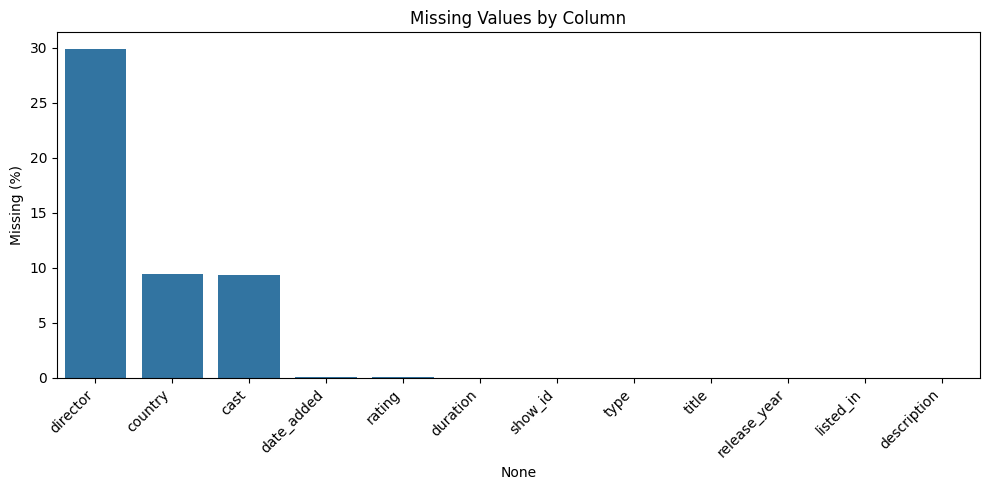

In [8]:
plt.figure()
sns.barplot(x=missing_df.index, y="missing_percent", data=missing_df)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing (%)")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

In [9]:
# Convert date_added to datetime
# Ensure the column is string type and strip whitespace before converting to datetime
df["date_added"] = pd.to_datetime(df["date_added"].astype(str).str.strip(), errors='coerce')

# Standardize text fields to avoid weird spacing
for col in ["type", "rating", "listed_in", "country"]:
    df[col] = df[col].astype(str).str.strip()

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",nan,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,nan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
type_counts = df["type"].value_counts()
type_counts

,count
type,
Movie,6131
TV Show,2676


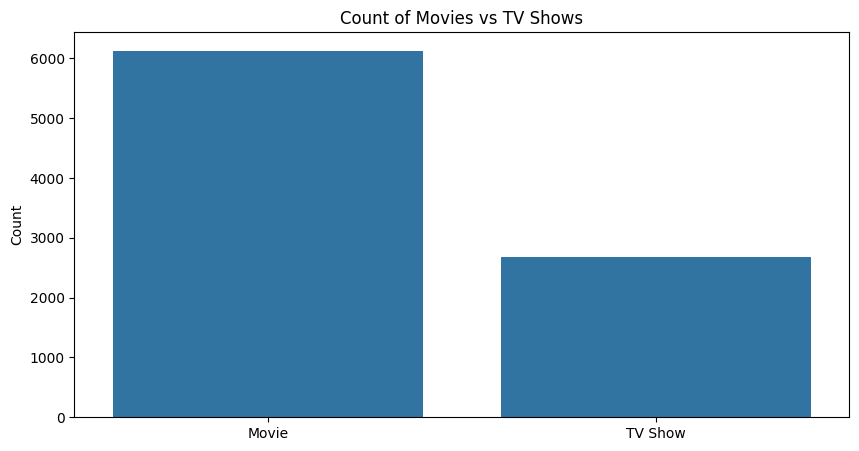

In [11]:
plt.figure()
sns.countplot(x="type", data=df)
plt.title("Count of Movies vs TV Shows")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

In [12]:
year_counts = df["release_year"].value_counts().sort_index()
year_counts.tail(20)  # last 20 years

,count
release_year,
2002,51
2003,61
2004,64
2005,80
2006,96
2007,88
2008,136
2009,152
2010,194


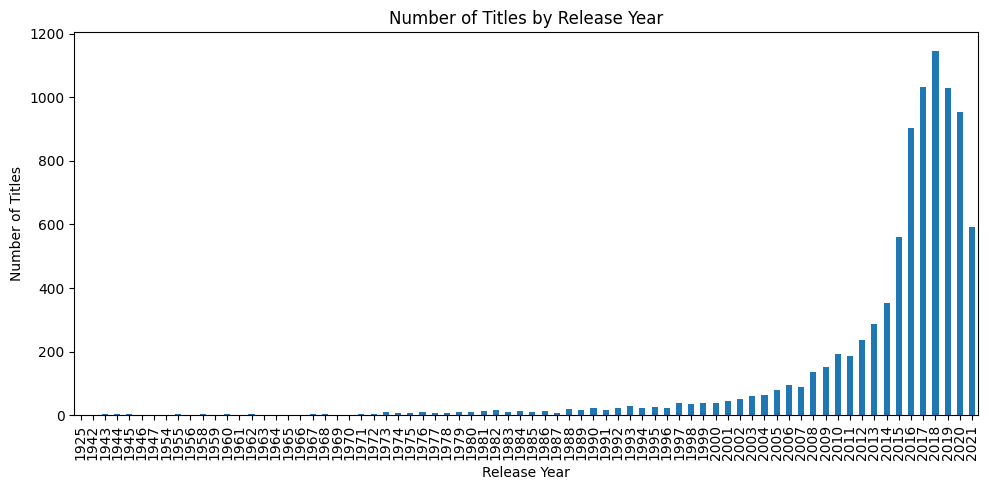

In [13]:
plt.figure()
year_counts.plot(kind="bar")
plt.title("Number of Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

In [14]:
rating_counts = df["rating"].value_counts().sort_values(ascending=False)
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


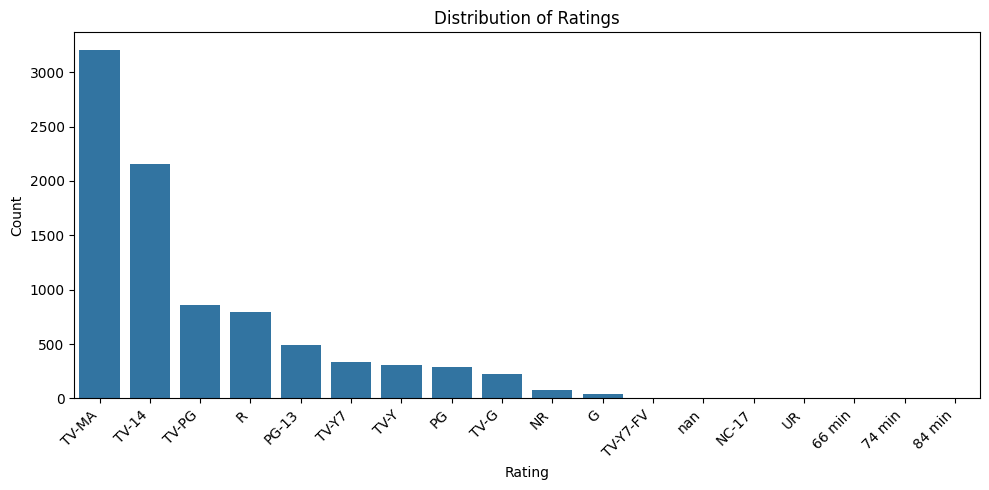

In [15]:
plt.figure()
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Ratings")
plt.ylabel("Count")
plt.xlabel("Rating")
plt.tight_layout()
plt.show()

In [16]:
# 'country' often has multiple comma-separated countries; take the first as a simple approximation
df["main_country"] = df["country"].str.split(",").str[0].str.strip()
country_counts = df["main_country"].value_counts().head(15)
country_counts

,count
main_country,
United States,3211
India,1008
nan,831
United Kingdom,628
Canada,271
Japan,259
France,212
South Korea,211
Spain,181


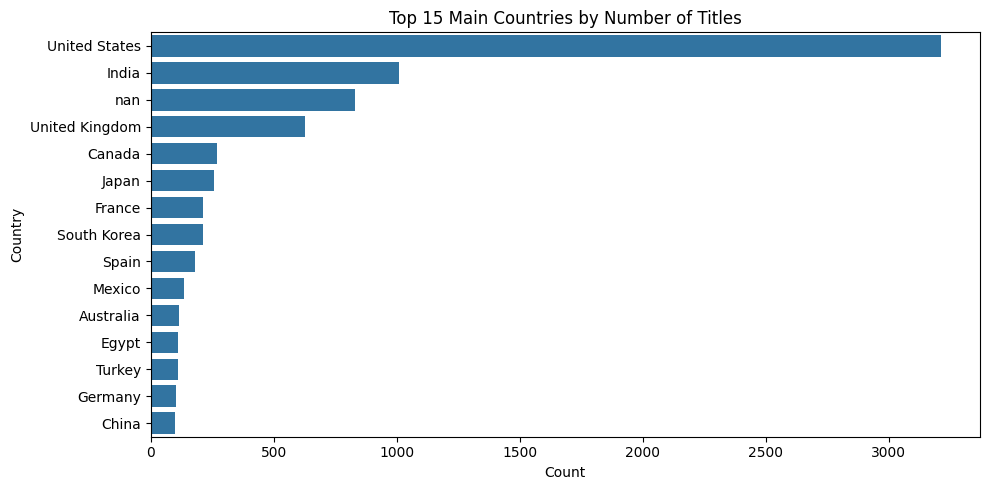

In [17]:
plt.figure()
sns.barplot(y=country_counts.index, x=country_counts.values)
plt.title("Top 15 Main Countries by Number of Titles")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Part 3 – My Add-On Analyses

In this section, I extend the original project by performing additional, more advanced
analyses using the same dataset. Each subsection follows the pattern:



## 3.1 Time-Based Catalog Growth

In [18]:
# Create a year_added column from date_added
df["year_added"] = df["date_added"].dt.year

# Filter to rows with valid year_added
df_year = df.dropna(subset=["year_added"]).copy()
df_year["year_added"] = df_year["year_added"].astype(int)

growth = df_year.groupby(["year_added", "type"])["show_id"].count().reset_index()
growth = growth.rename(columns={"show_id": "title_count"})

growth.head()

,year_added,type,title_count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13


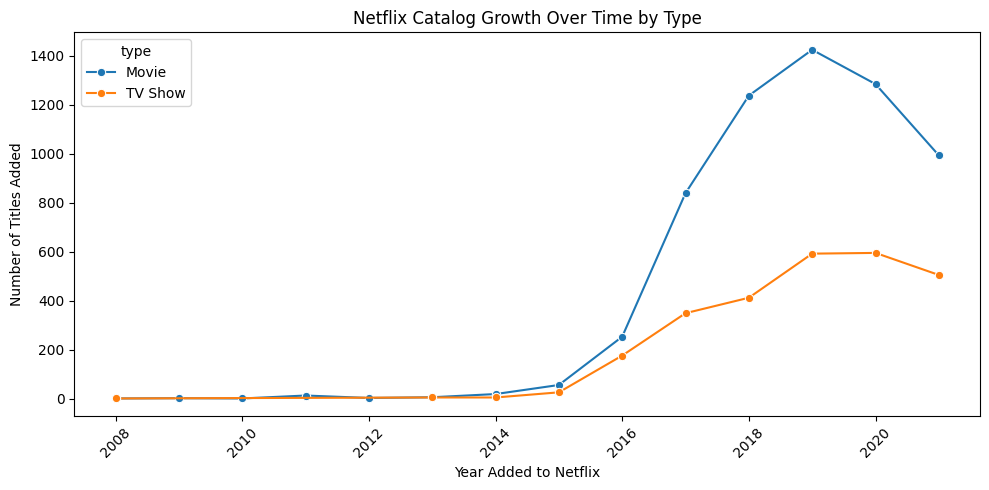

In [19]:
plt.figure()
sns.lineplot(data=growth, x="year_added", y="title_count", hue="type", marker="o")
plt.title("Netflix Catalog Growth Over Time by Type")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**  
This plot shows that the number of titles added to Netflix has increased sharply since around
2014–2015. Movies make up a larger share of the catalog overall, but TV Shows also grow
over time. The trend suggests that Netflix has been expanding its library aggressively in
recent years, especially for streaming-friendly content.


## 3.2 Regional and Rating Patterns

In [31]:
top_countries = df["main_country"].value_counts().head(10).index
df_top_countries = df[df["main_country"].isin(top_countries)]

country_type_counts = (
    df_top_countries.groupby(["main_country", "type"])["show_id"]
    .count()
    .reset_index()
    .rename(columns={"show_id": "count"})
)

country_type_counts

,main_country,type,count
0,Canada,Movie,187
1,Canada,TV Show,84
2,France,Movie,148
3,France,TV Show,64
4,India,Movie,927
5,India,TV Show,81
6,Japan,Movie,85
7,Japan,TV Show,174
8,Mexico,Movie,86
9,Mexico,TV Show,48


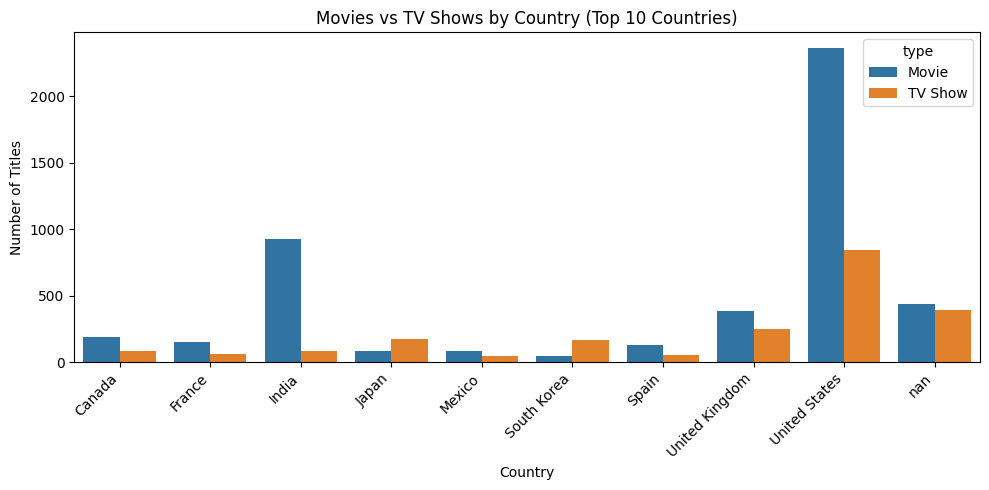

In [21]:
plt.figure()
sns.barplot(data=country_type_counts, x="main_country", y="count", hue="type")
plt.xticks(rotation=45, ha="right")
plt.title("Movies vs TV Shows by Country (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

In [22]:
rating_type_crosstab = pd.crosstab(df["rating"], df["type"])
rating_type_crosstab

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


<Figure size 1000x500 with 0 Axes>

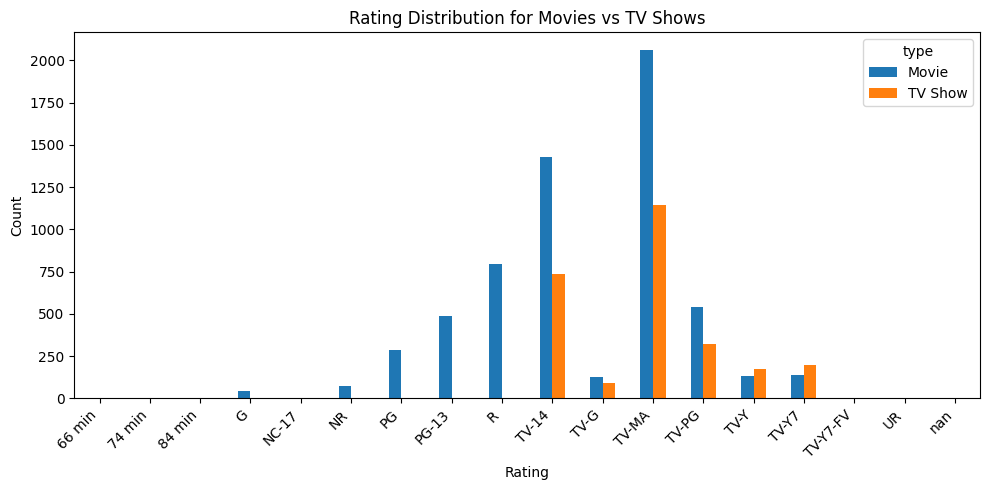

In [23]:
plt.figure()
rating_type_crosstab.sort_index().plot(kind="bar", stacked=False)
plt.title("Rating Distribution for Movies vs TV Shows")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interpretation:**  
The country-type bar chart highlights that countries like the United States, India, and the
United Kingdom contribute a large share of Netflix content, with Movies generally outnumbering
TV Shows, though the exact mix differs by country. The rating vs. type comparison shows
that certain ratings (such as TV-MA and TV-14) are heavily represented among TV Shows,
while others (like PG and R) are more associated with Movies. This suggests that Netflix’s
content strategy varies by region and format, and that mature-audience content is especially
prominent in the TV catalog.


## 3.3 Text Analysis of Descriptions

In [24]:
# Simple text cleaning for descriptions
df["description"] = df["description"].astype(str)

# Lowercase and remove punctuation
df["description_clean"] = (
    df["description"]
    .str.lower()
    .str.replace("[^a-z\s]", "", regex=True)
)

# Split into words and explode
words_series = df["description_clean"].str.split().explode()

# Remove very short words and a simple custom stopword list
stopwords = set([
    "the", "and", "a", "an", "of", "to", "in", "on", "for",
    "is", "with", "as", "this", "that", "his", "her", "their",
    "by", "from", "about", "at", "be", "it"
])

words_series = words_series[~words_series.isin(stopwords)]
words_series = words_series[words_series.str.len() > 2]

top_words = words_series.value_counts().head(20)
top_words

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2335331149.py:8: SyntaxWarning: invalid escape sequence '\s'
  .str.replace("[^a-z\s]", "", regex=True)


,count
description_clean,
when,1517
after,993
who,813
but,806
life,774
young,728
into,715
new,699
family,570


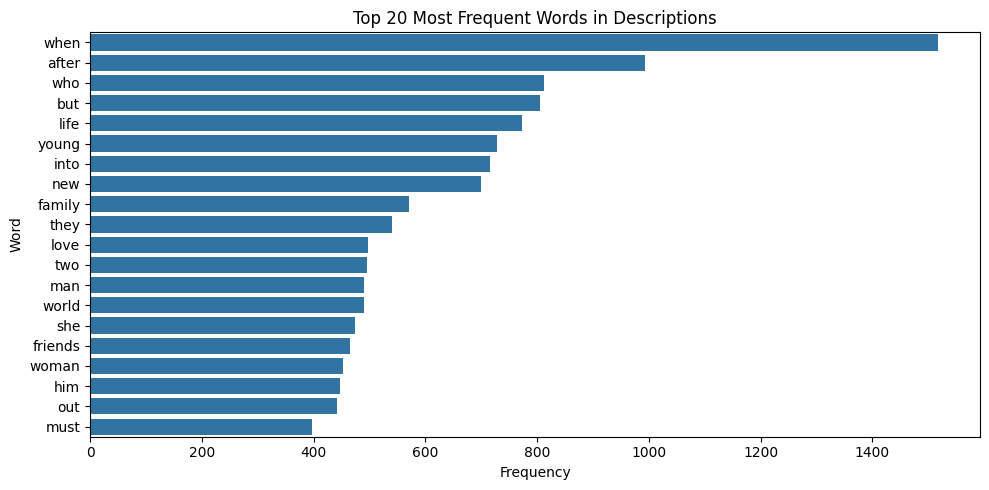

In [25]:
plt.figure()
sns.barplot(y=top_words.index, x=top_words.values)
plt.title("Top 20 Most Frequent Words in Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**Interpretation:**  
The most frequent words in the synopsis text often highlight recurring themes in Netflix
content, such as relationships, family, crime, love, and life. This quick text-based analysis
gives a high-level view of how Netflix markets its shows and movies and which themes
are most consistently emphasized in descriptions.


## 3.4 Simple Content-Based Recommendation (TF–IDF)

In [26]:
# Limit to non-null descriptions and reset index so we can map index  title easily
df_reco = df.dropna(subset=["description"]).reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_reco["description"])

tfidf_matrix.shape

(8807, 5000)

In [27]:
# Precompute cosine similarity (this can be large but okay for this dataset)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim.shape

(8807, 8807)

In [28]:
# Map from title to index some titles may be duplicated, so we keep the first index
title_to_index = pd.Series(df_reco.index, index=df_reco["title"].str.lower()).drop_duplicates()

def recommend_similar_titles(title, top_n=10):
    """
    Given a title (string), return a DataFrame of the top_n most similar titles
    based on description text (TF-IDF cosine similarity).
    """
    title_lower = title.lower()
    if title_lower not in title_to_index:
        raise ValueError(f"Title '{title}' not found in dataset.")

    idx = title_to_index[title_lower]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Skip the first one because it's the title itself
    sim_scores = sim_scores[1 : top_n + 1]

    indices = [i for i, score in sim_scores]
    scores = [score for i, score in sim_scores]

    result = df_reco.loc[indices, ["title", "type", "rating", "main_country"]].copy()
    result["similarity_score"] = np.round(scores, 3)
    return result

In [29]:
# Example
df_reco["title"].sample(10, random_state=42)

,title
4970,"Game Over, Man!"
3362,Arsenio Hall: Smart & Classy
5494,Kazoops!
1688,We Are the Champions
1349,"Pablo Escobar, el patrón del mal"
4862,Saint Seiya: The Lost Canvas
2676,Fauda
487,The Cook of Castamar
1671,The App That Stole Christmas
5028,Mute


In [30]:
# recommend_similar_titles("Narcos", top_n=5)
recommend_similar_titles("Game Over, Man!", top_n=5)

,title,type,rating,main_country,similarity_score
4984,Secret of the Nile,TV Show,TV-14,Egypt,0.196
8787,You Can’t Fight Christmas,Movie,TV-PG,United States,0.188
3766,Pachamama,Movie,PG,France,0.185
8091,Still,Movie,TV-MA,Thailand,0.161
8191,The Animal People,Movie,TV-MA,United States,0.159


**Interpretation:**  
This simple recommendation function uses TF–IDF to represent each description as a
vector and cosine similarity to measure how close two shows or movies are in that vector
space. For a given title, the function returns other titles whose descriptions share similar
keywords and themes. While this is not a full production-level recommendation system,
it demonstrates how we can turn text features into quantitative representations and use
them to provide content-based recommendations.


#Conclusions

In this project, I replicated and extended a Kaggle-based exploratory data analysis of the
**“Netflix Movies and TV Shows”** dataset. The original project focused on basic cleaning,
exploratory visualizations, and high-level descriptive statistics, such as the distribution of
Movies vs TV Shows, release years, ratings, and top countries.

My add-on analyses provided additional insights:

1. **Time-based catalog growth** showed that Netflix has expanded its library significantly
   in recent years, especially after the mid-2010s, with growth in both Movies and TV Shows.
2. **Regional and rating patterns** revealed that a few countries (such as the US and India)
   dominate production, and that certain content ratings are more closely associated with
   TV Shows than Movies.
3. **Text analysis of descriptions** highlighted recurring themes that define Netflix’s content
   strategy, including crime, relationships, and family dynamics.
4. The **TF–IDF based recommendation function** illustrated how we can leverage textual
   metadata to find titles with similar descriptions, demonstrating a simple but concrete
   application of content-based recommendation techniques.

Overall, this project showcases an end-to-end Python data analysis workflow: loading,
cleaning, exploring, extending, and interpreting real-world streaming data.
